# Case study E8: 6-DoF powered descent by successive convexification

Successive convexification (SCvx, and its penalized trust region variant PTR) solves a nonconvex
trajectory problem as a sequence of convex subproblems: discretize the nonlinear dynamics about the
current trajectory, solve the convexified problem, repeat. OpenSCvx (JAX, with CVXPY and QOCO for the
subproblems) reports 1.6 to 2.1 s of initialization, dominated by JIT compilation, for a solve of
0.05 to 0.13 s.

This study takes OpenSCvx's 6-DoF rocket landing (`examples/rocket/6DoF_pdg.py`) and writes its PTR in
Scaly as one generated C function: the discretization (two Tsit5 steps per interval, sensitivities
carried through every stage) and the convex subproblem (a QP, solved by Scaly's generated PIQP inside
the loop), reproducing OpenSCvx's iterates. The Scaly cells run without OpenSCvx; the recorded
comparison is in `results/`. The write-up is `internal/notes/case_study_e8_report.html`.

In [1]:
import json
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

HERE = Path.cwd()
sys.path[:0] = [str(HERE), str(HERE.parent)]

import plotstyle
from scaly.codegen import render_c_module

import scaly_impl as si

plotstyle.use()
RUN_BASELINES = False  # True reruns compare.py: OpenSCvx and Scaly, cold and warm, five rounds (about five minutes); needs baseline/setup.sh
RESULTS = HERE / "results"

## The problem

A rocket with 14 states (mass, position, velocity, attitude quaternion, angular rate) and body-frame
thrust lands at the origin with maximal final mass. OpenSCvx augments the states with the time `t` and a
penalty state `y` whose rate is the squared violation of every continuous-time constraint (the state
boxes, the glide slope, the tilt, the gimbal, the thrust bounds, ...), and poses everything in
normalized time with a time dilation `s` as a control. Five nodes, free final time. `model.py` writes
the rates exactly as the example does; `results/reference_6dof.json` holds OpenSCvx's run, every
iteration's discretization and subproblem solution included.

In [2]:
ref = json.loads((RESULTS / "reference_6dof.json").read_text())
d = si.Data(ref)
print(
  f"N = {si.N} nodes, {si.NX} states, {si.NU} controls; OpenSCvx converged in {len(ref['iterations'])} PTR iterations "
  f"to final mass {ref['final']['final_mass']:.7f} and t_f = {ref['final']['t_f']:.6f} s"
)

N = 5 nodes, 16 states, 4 controls; OpenSCvx converged in 5 PTR iterations to final mass 1.4171783 and t_f = 8.485601 s


## The discretization

On each interval the augmented rates `s f(x, u(tau))` are integrated by two fixed Tsit5 steps (diffrax's
coefficients), the thrust a first-order hold. OpenSCvx differentiates through the steps in forward mode.
Scaly carries the tangent `d x / d(x_k, u_k, u_{k+1})` through every stage by the variational equation,
calling one Function for the rates and their Jacobians: for an explicit Runge-Kutta step that is the
step's forward-mode derivative, stage for stage, and it keeps the generated code to one copy of the
rates' derivative. Against OpenSCvx's matrices at its iterations 1, 3 and 5:

In [3]:
disc = si.discretize_function(name="nb_discretize")
for it in (0, 2, 4):
  r = ref["iterations"][it]
  xp, A, B, C = (np.asarray(a) for a in disc(np.ravel(r["X_ref"]), np.ravel(r["U_ref"])))
  print(
    f"iteration {it + 1}: x_prop {np.abs(xp.reshape(4, 16) - np.array(r['x_prop'])).max():.1e}, "
    f"A_d {np.abs(A.reshape(4, 16, 16) - np.array(r['A_d'])).max():.1e}, B_d {np.abs(B.reshape(4, 16, 4) - np.array(r['B_d'])).max():.1e}, "
    f"C_d {np.abs(C.reshape(4, 16, 4) - np.array(r['C_d'])).max():.1e}"
  )

iteration 1: x_prop 4.6e-15, A_d 2.3e-14, B_d 2.3e-14, C_d 1.9e-14
iteration 3: x_prop 9.9e-15, A_d 4.6e-13, B_d 6.6e-14, C_d 4.1e-14
iteration 5: x_prop 4.7e-15, A_d 1.9e-14, B_d 2.4e-14, C_d 1.3e-14


## The whole PTR as one Function

Each iteration: discretize about the reference, build the subproblem's data, solve it with the generated
PIQP (a Function of the QP's parameters, called inside the loop), take the solution as the next
reference, stop when OpenSCvx's two tests pass. The first call renders and compiles the C.

In [4]:
t0 = time.perf_counter()
ptr = si.ptr_function(d, name="nb_ptr")
X, U, iters, jtr, jvc = ptr(np.ravel(d.X0), np.ravel(d.U0))
print(f"build, compile and first solve: {time.perf_counter() - t0:.1f} s")
samples = []
for _ in range(50):
  t = time.perf_counter()
  ptr(np.ravel(d.X0), np.ravel(d.U0))
  samples.append(time.perf_counter() - t)
X, U = np.asarray(X), np.asarray(U)
print(
  f"a whole solve through the Python call: {1e3 * min(samples):.2f} ms; {int(iters)} iterations, final mass {X[-1, 0]:.7f}, t_f {X[-1, 14]:.6f} s"
)
print(f"{'iteration':>9s} {'J_tr Scaly':>12s} {'J_tr OpenSCvx':>14s} {'J_vc Scaly':>11s} {'J_vc OpenSCvx':>14s}")
for k in range(int(iters)):
  r = ref["iterations"][k]
  print(f"{k + 1:9d} {jtr[k]:12.6g} {r['J_tr']:14.6g} {jvc[k]:11.3g} {r['J_vc']:14.3g}")
print(
  "largest difference from OpenSCvx's trajectory: states",
  np.abs(X - np.array(ref["final"]["X"])).max(),
  "controls",
  np.abs(U - np.array(ref["final"]["U"])).max(),
)
module = render_c_module(ptr)
print(f"{len(module.body.encode()) / 1e3:.0f} kB of C, workspace {module.workspace_size} doubles")

build, compile and first solve: 1.7 s
a whole solve through the Python call: 2.15 ms; 5 iterations, final mass 1.4171783, t_f 8.485601 s
iteration   J_tr Scaly  J_tr OpenSCvx  J_vc Scaly  J_vc OpenSCvx
        1      1.53547        1.53547      0.0491         0.0491
        2    0.0537572      0.0537572    0.000507       0.000507
        3   0.00735828     0.00735827    0.000397       0.000397
        4   0.00169488     0.00169488    0.000332       0.000332
        5  0.000216346    0.000216349    4.38e-15       8.32e-11
largest difference from OpenSCvx's trajectory: states 1.1654345755118811e-07 controls 4.512034038062218e-07


702 kB of C, workspace 74063 doubles


The last iteration's `J_vc` differs (4e-15 against 8e-11): OpenSCvx's QOCO stops at the example's
tolerances (`abstol` 1e-6), Scaly's PIQP here at 1e-9; the trajectories agree to QOCO's tolerance.

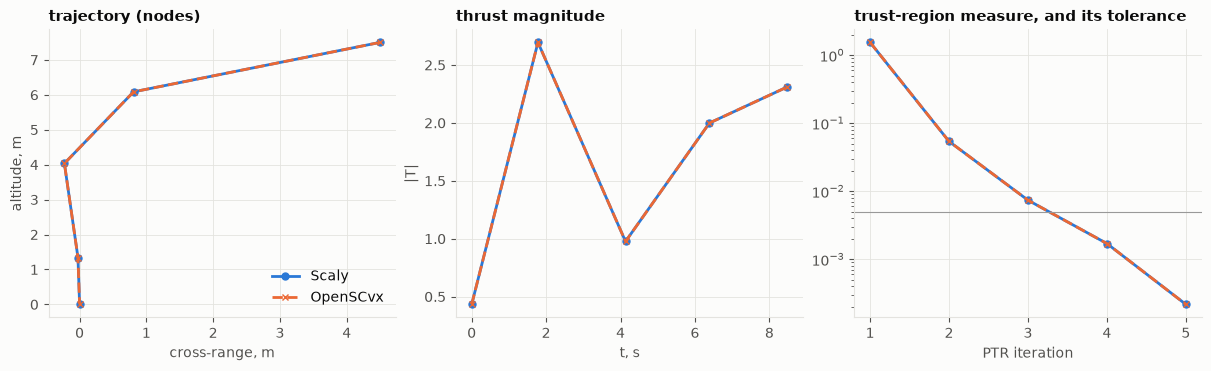

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
tt, tt_ref = X[:, 14], np.array(ref["final"]["X"])[:, 14]  # the nodes' physical times: the time state
axes[0].plot(X[:, 2], X[:, 1], "o-", color="C0", label="Scaly")
axes[0].plot(np.array(ref["final"]["X"])[:, 2], np.array(ref["final"]["X"])[:, 1], "x--", color="C1", label="OpenSCvx")
axes[0].set_xlabel("cross-range, m")
axes[0].set_ylabel("altitude, m")
axes[0].set_title("trajectory (nodes)")
axes[0].legend(frameon=False)
axes[1].plot(tt, np.linalg.norm(U[:, :3], axis=1), "o-", color="C0")
axes[1].plot(tt_ref, np.linalg.norm(np.array(ref["final"]["U"])[:, :3], axis=1), "x--", color="C1")
axes[1].set_xlabel("t, s")
axes[1].set_ylabel("|T|")
axes[1].set_title("thrust magnitude")
axes[2].semilogy(np.arange(1, int(iters) + 1), jtr[: int(iters)], "o-", color="C0", label="J_tr")
axes[2].semilogy(np.arange(1, int(iters) + 1), [r["J_tr"] for r in ref["iterations"]], "x--", color="C1")
axes[2].axhline(d.ep_tr, color="0.6", lw=0.8)
axes[2].set_xlabel("PTR iteration")
axes[2].set_title("trust-region measure, and its tolerance")
plt.show()

## End to end

`compare.py` runs both in fresh processes, cold (empty caches) and warm (the caches of the cold run),
five rounds, and times the phases each tool separates: imports; building the problem; OpenSCvx's
`initialize()` (tracing, XLA compilation, CVXPY canonicalization, a warm-up iteration) or Scaly's first
call (C generation, compile, first solve); and the solve.

In [6]:
if RUN_BASELINES:
  subprocess.run([sys.executable, str(HERE / "compare.py"), "--out", str(RESULTS / "compare.json")], check=True)
rows = json.loads((RESULTS / "compare.json").read_text())["rows"]
from compare import end_to_end, parts, table

print(table(rows))
print()
print(parts(rows))

| Stack | Start | Imports, s | Build, s | Compile and first solve, s | End to end, s | Solve, ms | PTR iterations | Final mass |
|---|---|---|---|---|---|---|---|---|
| openscvx | cold | 1.08 | 0.37 | 3.12 | 4.61 | 43.84 | 5 | 1.4171783 |
| openscvx | warm | 1.07 | 0.37 | 3.16 | 4.64 | 45.25 | 5 | 1.4171783 |
| scaly | cold | 0.12 | 0.81 | 4.13 | 5.06 | 2.13 | 5 | 1.4171783 |
| scaly | warm | 0.13 | 0.32 | 1.38 | 1.83 | 2.13 | 5 | 1.4171783 |

| Per PTR iteration, ms | OpenSCvx | Scaly |
|---|---:|---:|
| whole iteration | 5.11 | 0.425 |
| QP solve | 0.558 (QOCO; CVXPY's call 2.19) | 0.346 |
| discretization | two per iteration, and the rest: 2.92 | 0.046 |


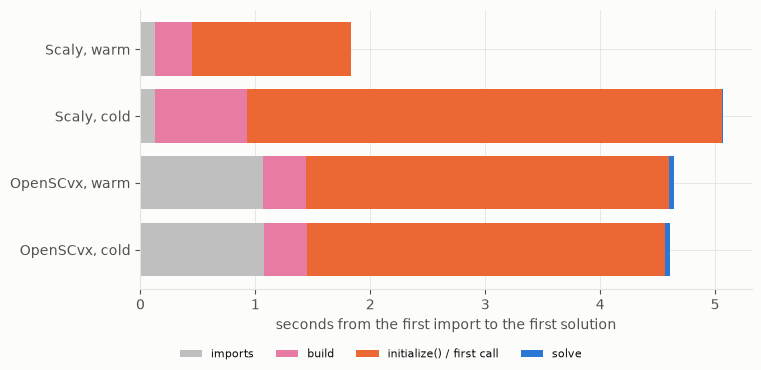

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 3.6), layout="constrained")
labels, phases = [], []
for stack, name in (("openscvx", "OpenSCvx"), ("scaly", "Scaly")):
  for start in ("cold", "warm"):
    r = min((x for x in rows if x["stack"] == stack and x["start"] == start), key=end_to_end)
    if stack == "openscvx":
      phases.append([r["t_import"], r["t_problem"], r["t_initialize"], r["t_solve"]])
    else:
      phases.append([r["t_import"], r["t_build"], r["t_first_call"] - r["solve_python_s"], r["solve_python_s"]])
    labels.append(f"{name}, {start}")
phases = np.array(phases)
left = np.zeros(len(labels))
for j, (lab, col) in enumerate(zip(("imports", "build", "initialize() / first call", "solve"), ("0.75", "C4", "C1", "C0"))):
  ax.barh(labels, phases[:, j], left=left, color=col, label=lab)
  left += phases[:, j]
ax.set_xlabel("seconds from the first import to the first solution")
fig.legend(frameon=False, fontsize=8, loc="outside lower center", ncol=4)
plt.show()

## Findings

- **The same iterates.** Five PTR iterations to final mass 1.4171783 and t_f 8.485601 s, both sides,
  the discretization equal to OpenSCvx's to 1e-14 and the trajectories to QOCO's tolerance.
- **The solve is 21x faster**: 2.1 against 44 ms. The QP solvers are close (PIQP 0.35 ms, QOCO 0.56 ms
  per iteration); the rest of OpenSCvx's 5 ms iteration is two discretizations in JAX, dispatched from
  Python, and CVXPY's interface, where Scaly's one discretization takes 46 us inside the same C function.
- **End to end it is level cold (5.1 against 4.6 s) and 2.5x warm (1.8 against 4.6 s)**; OpenSCvx's
  cache gives it nothing. The plan's 10x end to end is not met. Most of Scaly's warm start is rendering
  the C only to find the cached library (CS-16 in `internal/todo.md`).
- **This is the plan's Phase C on a QP**: OpenSCvx's example keeps every cone in its penalty state. The
  comparison with second-order cones in the subproblem needs them in the generated IPM (CS-17).